In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('World_Happiness_2015.csv')
df.head() # shows us that we have countries and their happiness-related metrics

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [3]:
df.info()
#reveals that we have 158 countries in total, with numerical columns like Happiness Score (stored as float64) and categorical ones like Region and Country (stored as object type).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

# 1. DATA AGGREGATION

Let's use aggregation to get a clearer picture by calculating summary statistics for different groups. For example, we might want to know the average happiness score for each region. we will use groupby() DataFrame method

In [4]:
grouped = df.groupby('Region')
df_grouped = grouped['Happiness Score']
happy_mean = df_grouped.mean()
happy_mean

"""
First, we group our data by Region using groupby()
Then, we select just the 'Happiness Score' column from our grouped data
Finally, we calculate the mean for each group using mean()
"""

"\nFirst, we group our data by Region using groupby()\nThen, we select just the 'Happiness Score' column from our grouped data\nFinally, we calculate the mean for each group using mean()\n"

Looking at the output, we can immediately spot some interesting patterns. Australia/New Zealand and North America show the highest average happiness scores (around 7.3), while Sub-Saharan Africa has the lowest (4.2). These kinds of patterns would be much harder to spot by looking at individual country data.

## Checking for outliers

In [5]:
# Z-score method (simple approach)
from scipy.stats import zscore

z_scores = df.select_dtypes(include='number').apply(zscore)
outliers = (abs(z_scores) > 3)
outliers.sum() 

Happiness Rank                   0
Happiness Score                  0
Standard Error                   3
Economy (GDP per Capita)         0
Family                           2
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    2
Generosity                       1
Dystopia Residual                1
dtype: int64

## Inspecting the outliers

In [6]:
# View only rows with outliers
outlier_mask = (z_scores.abs() > 3).any(axis=1)
df_outliers = df[outlier_mask]
df_outliers


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
27,Qatar,Middle East and Northern Africa,28,6.611,0.06257,1.69042,1.07860,0.79733,0.64040,0.52208,0.32573,1.55674
40,Trinidad and Tobago,Latin America and Caribbean,41,6.168,0.10895,1.21183,1.18354,0.61483,0.55884,0.01140,0.31844,2.26882
64,Jamaica,Latin America and Caribbean,65,5.709,0.13693,0.81038,1.15102,0.68741,0.50442,0.02299,0.21230,2.32038
115,Liberia,Sub-Saharan Africa,116,4.571,0.11068,0.07120,0.78968,0.34201,0.28531,0.06232,0.24362,2.77729
128,Myanmar,Southeastern Asia,129,4.307,0.04351,0.27108,0.70905,0.48246,0.44017,0.19034,0.79588,1.41805
147,Central African Republic,Sub-Saharan Africa,148,3.678,0.06112,0.07850,0.00000,0.06699,0.48879,0.08289,0.23835,2.72230
153,Rwanda,Sub-Saharan Africa,154,3.465,0.03464,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042
155,Syria,Middle East and Northern Africa,156,3.006,0.05015,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
157,Togo,Sub-Saharan Africa,158,2.839,0.06727,0.20868,0.13995,0.28443,0.36453,0.10731,0.16681,1.56726


## Statistical Summary

In [7]:
# Basic overview
df.describe(include='all')


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158,158,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
unique,158,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Switzerland,Sub-Saharan Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,NaN,NaN,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,NaN,NaN,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,NaN,NaN,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,NaN,NaN,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,NaN,NaN,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415


In [8]:
## Checking Duplicates
#df.duplicated()
# Count and show duplicates
duplicates = df[df.duplicated()]
print(f"Duplicate rows: {len(duplicates)}")



Duplicate rows: 0


## Group-Based Aggregation

In [9]:
# Group by Region and compute key stats
region_stats = df.groupby('Region').agg({
    'Happiness Score': ['mean', 'median', 'min', 'max', 'std'],
    'Economy (GDP per Capita)': 'mean',
    'Health (Life Expectancy)': 'mean'
})
region_stats


Happiness Score                       \
                                           mean median    min    max   
Region                                                                 
Australia and New Zealand              7.285000  7.285  7.284  7.286   
Central and Eastern Europe             5.332931  5.286  4.218  6.505   
Eastern Asia                           5.626167  5.729  4.874  6.298   
Latin America and Caribbean            6.144682  6.149  4.518  7.226   
Middle East and Northern Africa        5.406900  5.262  3.006  7.278   
North America                          7.273000  7.273  7.119  7.427   
Southeastern Asia                      5.317444  5.360  3.819  6.798   
Southern Asia                          4.580857  4.565  3.575  5.253   
Sub-Saharan Africa                     4.202800  4.272  2.839  5.477   
Western Europe                         6.689619  6.937  4.857  7.587   

                                          Economy (GDP per Capita)  \
                                      std                     mean   
Region                                                               
Australia and New Zealand        0.001414                 1.291880   
Central and Eastern Europe       0.570446                 0.942438   
Eastern Asia                     0.554053                 1.151780   
Latin America and Caribbean      0.728560                 0.876815   
Middle East and Northern Africa  1.101382                 1.066974   
North America                    0.217789                 1.360400   
Southeastern Asia                0.950020                 0.789054   
Southern Asia                    0.570526                 0.560486   
Sub-Saharan Africa               0.609557                 0.380473   
Western Europe                   0.824582                 1.298596   

                                Health (Life Expectancy)  
                                                    mean  
Region                                                    
Australia and New Zealand                       0.919965  
Central and Eastern Europe                      0.718774  
Eastern Asia                                    0.877388  
Latin America and Caribbean                     0.703870  
Middle East and Northern Africa                 0.705615  
North America                                   0.883710  
Southeastern Asia                               0.677357  
Southern Asia                                   0.540830  
Sub-Saharan Africa                              0.282332  
Western Europe                                  0.909148

## Visualize Distributions

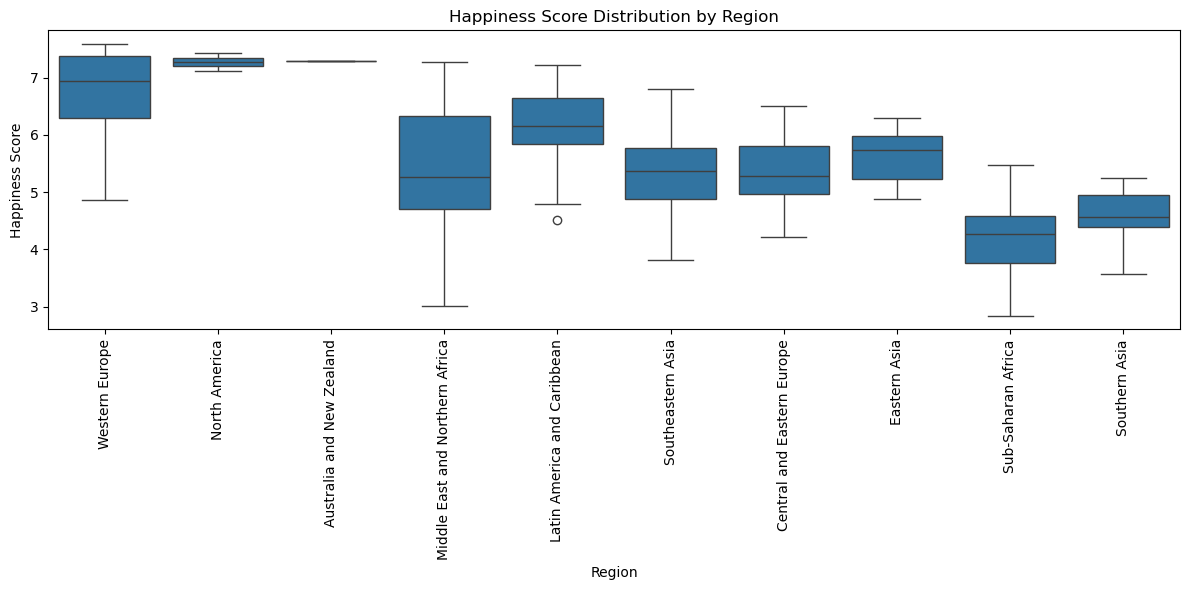

In [10]:
# Distribution of Happiness Score by Region
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Region', y='Happiness Score')
plt.xticks(rotation=90)
plt.title('Happiness Score Distribution by Region')
plt.tight_layout()
plt.show()


1. Wealthier regions (e.g., Western Europe, North America) show high and consistent happiness.

2. Developing regions like Sub-Saharan Africa and Southern Asia show lower scores and more variability, possibly due to economic and political differences.

3. Outliers in several regions hint at countries that are either performing unusually well or struggling despite their region’s norm.

# 2. Combining Data Using Pandas

we've explored the 2015 World Happiness Report data, but what if we want to analyze how happiness scores change over time, we'll need data from multiple years. This is a common scenario in data analysis―the information you need often lives in different files or comes from different sources.eg we will use 

1. World Happiness Report 2015

2. World Happiness Report 2016

3. World Happiness Report 2017

##  let's load our data and add a year column to each dataset so we can track changes over time:



In [11]:
happiness2015 = pd.read_csv("World_Happiness_2015.csv")
happiness2016 = pd.read_csv('World_Happiness_2016.csv')
happiness2017 = pd.read_csv('World_Happiness_2017.csv')

happiness2015['Year'] = 2015
happiness2016['Year'] = 2016
happiness2017['Year'] = 2017

## Let's explore the concat() method
this method is used when you want to stack datasets on top of each other or side by side.
1. vertically like adding more rows
2. horizontally like adding more columns

In [12]:
head_2015 = happiness2015[['Country','Happiness Score', 'Year']].head(3)
head_2016 = happiness2016[['Country','Happiness Score', 'Year']].head(3)

# Vertical stacking (like adding more rows)
concat_axis0 = pd.concat([head_2015, head_2016], axis=0)
print(concat_axis0)



       Country  Happiness Score  Year
0  Switzerland            7.587  2015
1      Iceland            7.561  2015
2      Denmark            7.527  2015
0      Denmark            7.526  2016
1  Switzerland            7.509  2016
2      Iceland            7.501  2016


In [13]:
# Horizontal stacking (like adding more columns)
concat_axis1 = pd.concat([head_2015, head_2016], axis=1)
print(concat_axis1)

       Country  Happiness Score  Year      Country  Happiness Score  Year
0  Switzerland            7.587  2015      Denmark            7.526  2016
1      Iceland            7.561  2015  Switzerland            7.509  2016
2      Denmark            7.527  2015      Iceland            7.501  2016


## Let's now explore the merge() methods
This one merges dataset based on matching values rather than position...this is the most recommended method

In [14]:
three_2015 = happiness2015[['Country','Happiness Rank','Year']].iloc[2:5]
three_2016 = happiness2016[['Country','Happiness Rank','Year']].iloc[2:5]

merged = pd.merge(left=three_2015, right=three_2016, on='Country', suffixes=('_2015','_2016'))
merged

,Country,Happiness Rank_2015,Year_2015,Happiness Rank_2016,Year_2016
0,Norway,4,2015,4,2016


 pd.merge() only kept Norway in the result―it was the only country present in both datasets. This behavior is similar to an inner join in SQL, keeping only the records that match in both datasets. This is exactly what we want when tracking changes over time for specific countries.

##### Use pd.concat() when:

You want to add new rows (axis=0) or columns (axis=1) based on position
Your datasets share the same structure (like combining happiness data from different years)
You don't need to match records based on specific values

##### Use pd.merge() when:

You need to combine data based on matching values (like country names)
You want control over how unmatched records are handled
Your datasets have different structures but share some common columns

### Validating Combined Data

Before moving forward with analysis, always validate your combined data by checking:

1. Row counts: Did you lose or gain the expected number of records?
2. Column names: Are there duplicate columns or unexpected suffixes?
3. Sample records: Do the combinations make sense for your analysis?
4. Missing values: Did the combination create any unexpected gaps?

# 3. Transforming data

 Transformations allow you to reshape, standardize, and enrich your dataset, ensuring everything lines up for analysis. When working on my weather prediction project, I had to align different metrics and units across multiple sources, which made the trends and patterns I observed trustworthy. Transforming data with pandas is an essential skill that will let you trust the insights you uncover hidden within messy, raw data.

Continuing with our 2015 World Happiness Report data, let's explore how to transform our data into more meaningful formats. Pandas provides several methods for this: Series.map(), Series.apply(), and DataFrame.map(). Each has its strengths, and knowing when to use each one will make your data transformations more efficient.

Continuing with our 2015 World Happiness Report data, let's explore how to transform our data into more meaningful formats

In [15]:
# Suppose you want to label countries as either with 'low' or 'high' haapiness
#df['Happiness_Label'] = df['Happiness Score'].map(lambda x: 'High' if x > 6 else 'Low')
#df.head()
"""
i abandoned this code because lambda function still confuses me.Any help and commentary will be appreciated 

"""

'\ni abandoned this code because lambda function still confuses me.Any help and commentary will be appreciated \n\n'

In [16]:
def label(element):
    if element > 1:
        return 'High'
    else:
        return 'Low'

happiness2015['Economy Impact'] = happiness2015['Economy (GDP per Capita)'].map(label)
happiness2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Year,Economy Impact
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015,High
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015,High
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015,High
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015,High
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015,High


In [17]:
# Define the factors we want to analyze
factors = ['Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity']

def percentages(col):
    div = col / happiness2015['Happiness Score']
    return div * 100
factor_percentages = happiness2015[factors].apply(percentages)
factor_percentages

,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity
0,18.406617,17.787136,12.408462,8.772506,5.532885,3.911691
1,17.224177,18.545563,12.535908,8.315963,1.870784,5.770401
2,17.609672,18.075993,11.620035,8.627342,6.424472,4.535539
3,19.396437,17.694097,11.768280,8.903616,4.852832,4.613002
4,17.857681,17.808132,12.193753,8.522553,4.437458,6.168170
...,...,...,...,...,...,...
153,6.409235,22.329004,12.370563,17.085426,15.928139,6.530447
154,8.582335,10.594611,9.553892,14.505988,2.398204,5.467066
155,22.062542,15.798071,24.016301,5.217565,6.289421,15.694943
156,0.526678,14.315663,7.709466,4.079174,3.463683,6.790706


##### Use Series.map() when:

You need a simple transformation on a single column

Your function doesn't require additional arguments

You want the clearest, most straightforward code

##### Use Series.apply() when:

Your function needs additional arguments

You want to apply more complex logic to each element

You need more flexibility in your transformation

##### Use DataFrame.map() when:

You need to transform multiple columns at once

You want to avoid repetitive code

Your transformation logic is consistent across columns

# 4. Working with strings in pandas

Real-world data isn’t always neatly formatted; you’ll often encounter messy strings with inconsistent capitalization, unexpected characters, or even extra spaces. Cleaning and standardizing string data is necessary for analysis and is especially common when working with text-heavy datasets, like survey responses or social media data. Learning to manipulate strings in pandas is a powerful skill that will help you prepare data for accurate, meaningful insights.

 we'll combine our 2015 World Happiness Report data with a dataset of economic information from the World Bank

In [18]:
world_dev = pd.read_csv("World_dev.csv")
col_renaming = {'SourceOfMostRecentIncomeAndExpenditureData': 'IESurvey'}

# Merge datasets and rename the long column name
merged = pd.merge(left=happiness2015, right=world_dev, how='left',
                 left_on='Country', right_on='ShortName')
merged = merged.rename(col_renaming, axis=1)
merged.columns.tolist()

['Country',
 'Region_x',
 'Happiness Rank',
 'Happiness Score',
 'Standard Error',
 'Economy (GDP per Capita)',
 'Family',
 'Health (Life Expectancy)',
 'Freedom',
 'Trust (Government Corruption)',
 'Generosity',
 'Dystopia Residual',
 'Year',
 'Economy Impact',
 'CountryCode',
 'ShortName',
 'TableName',
 'LongName',
 'Alpha2Code',
 'CurrencyUnit',
 'SpecialNotes',
 'Region_y',
 'IncomeGroup',
 'Wb2Code',
 'NationalAccountsBaseYear',
 'NationalAccountsReferenceYear',
 'SnaPriceValuation',
 'LendingCategory',
 'OtherGroups',
 'SystemOfNationalAccounts',
 'AlternativeConversionFactor',
 'PppSurveyYear',
 'BalanceOfPaymentsManualInUse',
 'ExternalDebtReportingStatus',
 'SystemOfTrade',
 'GovernmentAccountingConcept',
 'ImfDataDisseminationStandard',
 'LatestPopulationCensus',
 'LatestHouseholdSurvey',
 'IESurvey',
 'VitalRegistrationComplete',
 'LatestAgriculturalCensus',
 'LatestIndustrialData',
 'LatestTradeData',
 'LatestWaterWithdrawalData']

In [19]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 45 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region_x                       158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
 12  Year                           158 non-null    int

In [20]:
merged[['Country', 'CurrencyUnit']].head(10)


,Country,CurrencyUnit
0,Switzerland,Swiss franc
1,Iceland,Iceland krona
2,Denmark,Danish krone
3,Norway,Norwegian krone
4,Canada,Canadian dollar
5,Finland,Euro
6,Netherlands,Euro
7,Sweden,Swedish krona
8,New Zealand,New Zealand dollar
9,Australia,Australian dollar


This is how currency has been recorded in our dataset

Comparing String Processing Methods

To analyze currency patterns, we first need to extract just the currency type (franc, krona, dollar, etc.) from the full currency unit. Pandas offers two approaches for this task. First, let's try using the apply() method:

In [21]:
def extract_last_word(element):
    return str(element).split()[-1]
merged['Currency Apply'] = merged['CurrencyUnit'].apply(extract_last_word)

In [22]:
#While this works, pandas provides a more elegant solution using vectorized string operations:

merged['Currency Vectorized'] = merged['CurrencyUnit'].str.split().str.get(-1)
merged.head(3)

,Country,Region_x,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),...,LatestPopulationCensus,LatestHouseholdSurvey,IESurvey,VitalRegistrationComplete,LatestAgriculturalCensus,LatestIndustrialData,LatestTradeData,LatestWaterWithdrawalData,Currency Apply,Currency Vectorized
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,...,2010,NaN,"Expenditure survey/budget survey (ES/BS), 2004",Yes,2008,2010.0,2013.0,2000.0,franc,franc
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,...,2011,NaN,"Integrated household survey (IHS), 2010",Yes,2010,2005.0,2013.0,2005.0,krona,krona
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,...,2011,NaN,"Income tax registers (ITR), 2010",Yes,2010,2010.0,2013.0,2009.0,krone,krone


Best Practices for String Cleaning
When working with text data, follow these guidelines:

Start with a small sample to test your approach (as we did with the first few currencies)
Use vectorized methods for better performance and cleaner code
Chain operations together for complex transformations
Keep track of changes to ensure transformations work as expected
Document your standardization decisions (especially important with currency names, which might have multiple valid forms)

# Working with missing and duplicate data

Real-world datasets are rarely perfect. They often contain missing values, duplicates, and inconsistencies that can significantly impact your analysis

we'll work with modified versions of the World Happiness Report data:

2015 Dataset

2016 Dataset

2017 Dataset

In [23]:
happiness2015.columns.tolist() #check the columns for 2015 dataset

['Country',
 'Region',
 'Happiness Rank',
 'Happiness Score',
 'Standard Error',
 'Economy (GDP per Capita)',
 'Family',
 'Health (Life Expectancy)',
 'Freedom',
 'Trust (Government Corruption)',
 'Generosity',
 'Dystopia Residual',
 'Year',
 'Economy Impact']

In [24]:
happiness2016.columns.tolist()

['Country',
 'Region',
 'Happiness Rank',
 'Happiness Score',
 'Lower Confidence Interval',
 'Upper Confidence Interval',
 'Economy (GDP per Capita)',
 'Family',
 'Health (Life Expectancy)',
 'Freedom',
 'Trust (Government Corruption)',
 'Generosity',
 'Dystopia Residual',
 'Year']

In [25]:
happiness2017.columns.tolist()

['Country',
 'Happiness.Rank',
 'Happiness.Score',
 'Whisker.high',
 'Whisker.low',
 'Economy..GDP.per.Capita.',
 'Family',
 'Health..Life.Expectancy.',
 'Freedom',
 'Generosity',
 'Trust..Government.Corruption.',
 'Dystopia.Residual',
 'Year']

Notice the inconsistent formatting: parentheses, spaces, and mixed capitalization in the 2015 dataset. Let's clean these up:

In [26]:
happiness2015.columns = happiness2015.columns.str.replace('(', '').str.replace(')', '').str.strip().str.upper()
print(happiness2015.columns.tolist())


['COUNTRY', 'REGION', 'HAPPINESS RANK', 'HAPPINESS SCORE', 'STANDARD ERROR', 'ECONOMY GDP PER CAPITA', 'FAMILY', 'HEALTH LIFE EXPECTANCY', 'FREEDOM', 'TRUST GOVERNMENT CORRUPTION', 'GENEROSITY', 'DYSTOPIA RESIDUAL', 'YEAR', 'ECONOMY IMPACT']


In [27]:
# Clean column names across all datasets
happiness2015.columns = happiness2015.columns.str.replace('(', '').str.replace(')', '').str.strip().str.upper()
happiness2016.columns = happiness2016.columns.str.replace('(', '').str.replace(')', '').str.strip().str.upper()
happiness2017.columns = happiness2017.columns.str.replace('.', ' ').str.replace('s+', ' ', regex=True).str.strip().str.upper()

# Combine datasets
combined = pd.concat([happiness2015, happiness2016, happiness2017], ignore_index=True)
combined.head()


,COUNTRY,REGION,HAPPINESS RANK,HAPPINESS SCORE,STANDARD ERROR,ECONOMY GDP PER CAPITA,FAMILY,HEALTH LIFE EXPECTANCY,FREEDOM,TRUST GOVERNMENT CORRUPTION,...,UPPER CONFIDENCE INTERVAL,HAPPINE RANK,HAPPINE SCORE,WHI KER HIGH,WHI KER LOW,ECONOMY GDP PER CAPITA,HEALTH LIFE EXPECTANCY,GENERO ITY,TRU T GOVERNMENT CORRUPTION,DY TOPIA RE IDUAL
0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Norway,Western Europe,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Canada,North America,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Identifying missing values

In [28]:
print("Number of non-null values in each column:")
print(combined.notnull().sum().sort_values())

Number of non-null values in each column:
DY TOPIA RE IDUAL               155
WHI KER HIGH                    155
HAPPINE  SCORE                  155
HAPPINE  RANK                   155
TRU T  GOVERNMENT CORRUPTION    155
WHI KER LOW                     155
HEALTH  LIFE EXPECTANCY         155
ECONOMY  GDP PER CAPITA         155
GENERO ITY                      155
LOWER CONFIDENCE INTERVAL       157
UPPER CONFIDENCE INTERVAL       157
STANDARD ERROR                  158
ECONOMY IMPACT                  158
TRUST GOVERNMENT CORRUPTION     315
ECONOMY GDP PER CAPITA          315
DYSTOPIA RESIDUAL               315
HAPPINESS SCORE                 315
HAPPINESS RANK                  315
REGION                          315
HEALTH LIFE EXPECTANCY          315
GENEROSITY                      315
COUNTRY                         470
FAMILY                          470
FREEDOM                         470
YEAR                            470
dtype: int64


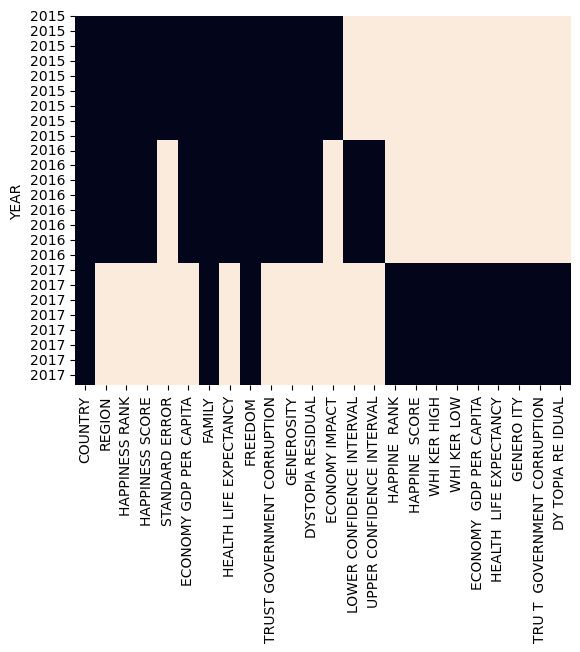

In [29]:
#visualizing the above info in a heatmap
import seaborn as sns
combined_updated = combined.set_index('YEAR')
sns.heatmap(combined_updated.isnull(), cbar=False)
plt.show()

The heatmap reveals:

some columns are completely missing for certain years (lighter regions)

some rows (countries) are missing data across most columns

only the COUNTRY column has complete data across all years (dark region)

In [30]:
# Drop columns with more than 330 missing values (keeping columns present in at least 2 years of data)
print(f"Columns before: {len(combined.columns)}")
combined = combined.dropna(thresh=159, axis=1)
print(f"Columns after: {len(combined.columns)}")
print("nRemaining columns:")
print(combined.columns.tolist())

Columns before: 25
Columns after: 12
nRemaining columns:
['COUNTRY', 'REGION', 'HAPPINESS RANK', 'HAPPINESS SCORE', 'ECONOMY GDP PER CAPITA', 'FAMILY', 'HEALTH LIFE EXPECTANCY', 'FREEDOM', 'TRUST GOVERNMENT CORRUPTION', 'GENEROSITY', 'DYSTOPIA RESIDUAL', 'YEAR']


In [31]:
# Now drop rows with missing values
rows_before = len(combined)
combined = combined.dropna()
print(f"Rows before: {rows_before}")
print(f"Rows after: {len(combined)}")
print(f"Percentage of data lost: {((rows_before - len(combined))/rows_before * 100):.1f}%")

Rows before: 470
Rows after: 315
Percentage of data lost: 33.0%


In [32]:
#checking duplicates
dups = combined.duplicated(['COUNTRY', 'YEAR'])
print(f"Number of duplicates: {dups.sum()}")
print(combined[dups][['COUNTRY', 'REGION', 'HAPPINESS RANK', 'HAPPINESS SCORE', 'YEAR']])

Number of duplicates: 0
Empty DataFrame
Columns: [COUNTRY, REGION, HAPPINESS RANK, HAPPINESS SCORE, YEAR]
Index: []


Through my experience , I've developed these guidelines for handling data quality issues:

Always examine your data before cleaning:

1. Check for missing values in each column
2. Look for duplicate entries
3. Visualize patterns (like we did with the heatmap)

Be strategic about handling missing values:

1. Consider why the data might be missing
2. Decide whether to drop or fill based on your analysis needs
3. Document your rationale for each decision

When removing data:

1. Keep your original dataset intact
2. Create copies for cleaning
3. Track how much data you're removing and why

Validate your cleaning steps:

1. Check summary statistics before and after cleaning
2. Look for unexpected changes in your data
3. Verify that relationships between variables remain sensible
